In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#from pathlib import Path
#import os
#import shutil
#import math
#import random

# import pandas as pd
# from PIL import Image

# PROJECT_DIR = Path("/content/drive/MyDrive/bee_yolo_project")
# EXTRACT_DIR = PROJECT_DIR / "extracted"

# FRAMES_DIR = EXTRACT_DIR / "frames"
# ANNOTATIONS_DIR = EXTRACT_DIR / "frames_txt"

# YOLO_DATASET_DIR = PROJECT_DIR / "yolo_bees_dataset_mini"

# CROP_SIZE = 512

# # Для первого теста берем 90 кадров
# MAX_FRAMES = 90

# # Эллипс для полностью видимой пчелы, как в статье Bozek:
# # semi-minor = 20, semi-major = 35
# ELLIPSE_A = 20
# ELLIPSE_B = 35

# # Круг для частично скрытой пчелы
# CIRCLE_R = 20

# POLYGON_POINTS = 32

# print("PROJECT_DIR:", PROJECT_DIR)
# print("FRAMES_DIR:", FRAMES_DIR)
# print("ANNOTATIONS_DIR:", ANNOTATIONS_DIR)
# print("YOLO_DATASET_DIR:", YOLO_DATASET_DIR)

PROJECT_DIR: /content/drive/MyDrive/bee_yolo_project
FRAMES_DIR: /content/drive/MyDrive/bee_yolo_project/extracted/frames
ANNOTATIONS_DIR: /content/drive/MyDrive/bee_yolo_project/extracted/frames_txt
YOLO_DATASET_DIR: /content/drive/MyDrive/bee_yolo_project/yolo_bees_dataset_mini


In [ ]:
# n = len(pairs)

# train_end = int(n * 0.7)
# val_end = int(n * 0.85)

# splits = {
#     "train": pairs[:train_end],
#     "val": pairs[train_end:val_end],
#     "test": pairs[val_end:]
# }

# for split_name, split_pairs in splits.items():
#     print(split_name, len(split_pairs))

In [ ]:
# def clip01(value):
#     return max(0.0, min(1.0, value))


# def make_ellipse_polygon(cx, cy, angle, a=ELLIPSE_A, b=ELLIPSE_B, n=POLYGON_POINTS):
#     """
#     cx, cy — центр пчелы внутри crop 512x512.
#     angle — угол из аннотации.
#     a, b — полуоси эллипса.
#     """
#     points = []

#     cos_t = math.cos(angle)
#     sin_t = math.sin(angle)

#     for i in range(n):
#         t = 2 * math.pi * i / n

#         # эллипс до поворота
#         x = a * math.cos(t)
#         y = b * math.sin(t)

#         # поворот
#         xr = x * cos_t - y * sin_t
#         yr = x * sin_t + y * cos_t

#         px = cx + xr
#         py = cy + yr

#         points.append((px, py))

#     return points


# def make_circle_polygon(cx, cy, r=CIRCLE_R, n=POLYGON_POINTS):
#     points = []

#     for i in range(n):
#         t = 2 * math.pi * i / n
#         px = cx + r * math.cos(t)
#         py = cy + r * math.sin(t)
#         points.append((px, py))

#     return points


# def polygon_to_yolo_line(points, class_id=0, crop_size=CROP_SIZE):
#     """
#     Переводим polygon в строку YOLO-Seg.
#     """
#     coords = []

#     for x, y in points:
#         x_norm = clip01(x / crop_size)
#         y_norm = clip01(y / crop_size)
#         coords.append(f"{x_norm:.6f}")
#         coords.append(f"{y_norm:.6f}")

#     return f"{class_id} " + " ".join(coords)

In [ ]:
# if YOLO_DATASET_DIR.exists():
#     shutil.rmtree(YOLO_DATASET_DIR)

# for split_name in ["train", "val", "test"]:
#     (YOLO_DATASET_DIR / "images" / split_name).mkdir(parents=True, exist_ok=True)
#     (YOLO_DATASET_DIR / "labels" / split_name).mkdir(parents=True, exist_ok=True)


Папки созданы


In [ ]:
# def read_annotation(ann_path):
#     ann = pd.read_csv(
#         ann_path,
#         sep=r"\s+",
#         header=None,
#         names=["offset_x", "offset_y", "source_class", "x", "y", "angle"]
#     )

#     return ann


# def process_pair(img_path, ann_path, split_name):
#     img = Image.open(img_path).convert("RGB")
#     ann = read_annotation(ann_path)

#     crops_created = 0
#     objects_created = 0

#     grouped = ann.groupby(["offset_x", "offset_y"])

#     for (offset_x, offset_y), crop_ann in grouped:
#         offset_x = int(offset_x)
#         offset_y = int(offset_y)

#         crop = img.crop((
#             offset_x,
#             offset_y,
#             offset_x + CROP_SIZE,
#             offset_y + CROP_SIZE
#         ))

#         crop_name = f"{img_path.stem}__x{offset_x}_y{offset_y}"
#         crop_img_path = YOLO_DATASET_DIR / "images" / split_name / f"{crop_name}.png"
#         crop_label_path = YOLO_DATASET_DIR / "labels" / split_name / f"{crop_name}.txt"

#         yolo_lines = []

#         for _, row in crop_ann.iterrows():
#             cx = float(row["x"])
#             cy = float(row["y"])
#             source_class = int(row["source_class"])
#             angle = float(row["angle"])

#             # Фильтр на случай странных точек
#             if cx < 0 or cx > CROP_SIZE or cy < 0 or cy > CROP_SIZE:
#                 continue

#             if source_class == 1:
#                 points = make_ellipse_polygon(cx, cy, angle)
#             elif source_class == 2:
#                 points = make_circle_polygon(cx, cy)
#             else:
#                 continue

#             #пока один класс: bee = 0
#             line = polygon_to_yolo_line(points, class_id=0)
#             yolo_lines.append(line)

#         if len(yolo_lines) == 0:
#             continue

#         crop.save(crop_img_path)

#         with open(crop_label_path, "w") as f:
#             f.write("\n".join(yolo_lines))

#         crops_created += 1
#         objects_created += len(yolo_lines)

#     return crops_created, objects_created


# total_crops = 0
# total_objects = 0

# for split_name, split_pairs in splits.items():
#     split_crops = 0
#     split_objects = 0

#     for img_path, ann_path in split_pairs:
#         crops_count, objects_count = process_pair(img_path, ann_path, split_name)
#         split_crops += crops_count
#         split_objects += objects_count

#     total_crops += split_crops
#     total_objects += split_objects

#     print(f"{split_name}: crops={split_crops}, objects={split_objects}")

# print("Итого crops:", total_crops)
# print("Итого objects:", total_objects)

train: crops=1488, objects=25456
val: crops=336, objects=5811
test: crops=336, objects=5784
Итого crops: 2160
Итого objects: 37051


In [ ]:
# yaml_text = f"""
# path: {YOLO_DATASET_DIR}
# train: images/train
# val: images/val
# test: images/test

# names:
#   0: bee
# """

# yaml_path = YOLO_DATASET_DIR / "data.yaml"

# with open(yaml_path, "w") as f:
#     f.write(yaml_text.strip())

# print(yaml_path)
# print(yaml_text)

/content/drive/MyDrive/bee_yolo_project/yolo_bees_dataset_mini/data.yaml

path: /content/drive/MyDrive/bee_yolo_project/yolo_bees_dataset_mini
train: images/train
val: images/val
test: images/test

names:
  0: bee



In [ ]:
for split_name in ["train", "val", "test"]:
    img_count = len(list((YOLO_DATASET_DIR / "images" / split_name).glob("*.png")))
    label_count = len(list((YOLO_DATASET_DIR / "labels" / split_name).glob("*.txt")))

    print(split_name)
    print("images:", img_count)
    print("labels:", label_count)
    print()

train
images: 1488
labels: 1488

val
images: 336
labels: 336

test
images: 336
labels: 336



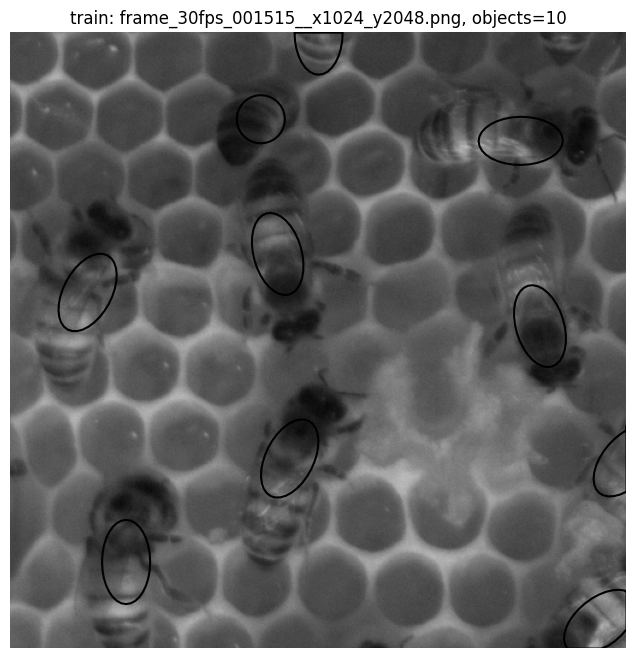

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon

def show_yolo_seg_sample(split_name="train", index=0):
    img_paths = sorted((YOLO_DATASET_DIR / "images" / split_name).glob("*.png"))
    label_paths = sorted((YOLO_DATASET_DIR / "labels" / split_name).glob("*.txt"))

    img_path = img_paths[index]
    label_path = YOLO_DATASET_DIR / "labels" / split_name / f"{img_path.stem}.txt"

    img = Image.open(img_path).convert("RGB")

    plt.figure(figsize=(8, 8))
    plt.imshow(img)

    with open(label_path, "r") as f:
        lines = f.readlines()

    for line in lines:
        parts = line.strip().split()
        class_id = int(parts[0])
        coords = list(map(float, parts[1:]))

        points = []
        for i in range(0, len(coords), 2):
            x = coords[i] * CROP_SIZE
            y = coords[i + 1] * CROP_SIZE
            points.append((x, y))

        poly = Polygon(points, fill=False, linewidth=1.5)
        plt.gca().add_patch(poly)

    plt.title(f"{split_name}: {img_path.name}, objects={len(lines)}")
    plt.axis("off")
    plt.show()

show_yolo_seg_sample("train", 0)

In [ ]:
from pathlib import Path

PROJECT_DIR = Path("/content/drive/MyDrive/bee_yolo_project")
YOLO_DATASET_DIR = PROJECT_DIR / "yolo_bees_dataset_mini"
DATA_YAML = YOLO_DATASET_DIR / "data.yaml"

print(DATA_YAML)
print(DATA_YAML.exists())
print(DATA_YAML.read_text())

/content/drive/MyDrive/bee_yolo_project/yolo_bees_dataset_mini/data.yaml
True
path: /content/drive/MyDrive/bee_yolo_project/yolo_bees_dataset_mini
train: images/train
val: images/val
test: images/test

names:
  0: bee


In [ ]:
for split_name in ["train", "val", "test"]:
    img_count = len(list((YOLO_DATASET_DIR / "images" / split_name).glob("*.png")))
    label_count = len(list((YOLO_DATASET_DIR / "labels" / split_name).glob("*.txt")))

    print(split_name)
    print("images:", img_count)
    print("labels:", label_count)
    print()

train
images: 1488
labels: 1488

val
images: 336
labels: 336

test
images: 336
labels: 336



In [ ]:
!pip install ultralytics -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 33.6 MB/s eta 0:00:00


In [ ]:
import ultralytics
ultralytics.checks()

Ultralytics 8.4.52 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 43.0/112.6 GB disk)


In [ ]:
from pathlib import Path

PROJECT_DIR = Path("/content/drive/MyDrive/bee_yolo_project")
YOLO_DATASET_DIR = PROJECT_DIR / "yolo_bees_dataset_mini"
DATA_YAML = YOLO_DATASET_DIR / "data.yaml"

print("DATA_YAML:", DATA_YAML)
print("exists:", DATA_YAML.exists())
print(DATA_YAML.read_text())

DATA_YAML: /content/drive/MyDrive/bee_yolo_project/yolo_bees_dataset_mini/data.yaml
exists: True
path: /content/drive/MyDrive/bee_yolo_project/yolo_bees_dataset_mini
train: images/train
val: images/val
test: images/test

names:
  0: bee


In [ ]:
from ultralytics import YOLO

model = YOLO("yolov8n-seg.pt")

results = model.train(
    data=str(DATA_YAML),
    task="segment",
    epochs=30,
    imgsz=512,
    batch=8,
    workers=2,
    patience=10,
    project=str(PROJECT_DIR / "runs"),
    name="yolov8n_seg_bees_mini",
    exist_ok=True
)

Ultralytics 8.4.52 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/bee_yolo_project/yolo_bees_dataset_mini/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=512, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8n_seg_bees_mini, nbs=64, nms=False, opset=None, opt

In [ ]:
from pathlib import Path
from ultralytics import YOLO

PROJECT_DIR = Path("/content/drive/MyDrive/bee_yolo_project")
YOLO_DATASET_DIR = PROJECT_DIR / "yolo_bees_dataset_mini"

best_model_path = PROJECT_DIR / "runs" / "yolov8n_seg_bees_mini" / "weights" / "best.pt"

model = YOLO(str(best_model_path))

test_images_dir = YOLO_DATASET_DIR / "images" / "test"

pred_results = model.predict(
    source=str(test_images_dir),
    imgsz=512,
    conf=0.25,
    save=True,
    project=str(PROJECT_DIR / "runs"),
    name="predictions_bees_mini",
    exist_ok=True
)


image 1/336 /content/drive/MyDrive/bee_yolo_project/yolo_bees_dataset_mini/images/test/frame_30fps_002655__x1024_y2048.png: 512x512 (no detections), 7.9ms
image 2/336 /content/drive/MyDrive/bee_yolo_project/yolo_bees_dataset_mini/images/test/frame_30fps_002655__x1024_y2560.png: 512x512 4 bees, 8.4ms
image 3/336 /content/drive/MyDrive/bee_yolo_project/yolo_bees_dataset_mini/images/test/frame_30fps_002655__x1024_y3072.png: 512x512 9 bees, 8.1ms
image 4/336 /content/drive/MyDrive/bee_yolo_project/yolo_bees_dataset_mini/images/test/frame_30fps_002655__x1024_y3584.png: 512x512 5 bees, 10.2ms
image 5/336 /content/drive/MyDrive/bee_yolo_project/yolo_bees_dataset_mini/images/test/frame_30fps_002655__x1536_y2048.png: 512x512 6 bees, 11.0ms
image 6/336 /content/drive/MyDrive/bee_yolo_project/yolo_bees_dataset_mini/images/test/frame_30fps_002655__x1536_y2560.png: 512x512 4 bees, 9.8ms
image 7/336 /content/drive/MyDrive/bee_yolo_project/yolo_bees_dataset_mini/images/test/frame_30fps_002655__x1536

In [ ]:
pred_results = model.predict(
    source=str(test_images_dir),
    imgsz=512,
    conf=0.05,
    iou=0.4,
    max_det=1000,
    save=True,
    project=str(PROJECT_DIR / "runs"),
    name="predictions_bees_mini_conf005",
    exist_ok=True
)


image 1/336 /content/drive/MyDrive/bee_yolo_project/yolo_bees_dataset_mini/images/test/frame_30fps_002655__x1024_y2048.png: 512x512 8 bees, 8.5ms
image 2/336 /content/drive/MyDrive/bee_yolo_project/yolo_bees_dataset_mini/images/test/frame_30fps_002655__x1024_y2560.png: 512x512 18 bees, 7.5ms
image 3/336 /content/drive/MyDrive/bee_yolo_project/yolo_bees_dataset_mini/images/test/frame_30fps_002655__x1024_y3072.png: 512x512 25 bees, 7.2ms
image 4/336 /content/drive/MyDrive/bee_yolo_project/yolo_bees_dataset_mini/images/test/frame_30fps_002655__x1024_y3584.png: 512x512 14 bees, 7.2ms
image 5/336 /content/drive/MyDrive/bee_yolo_project/yolo_bees_dataset_mini/images/test/frame_30fps_002655__x1536_y2048.png: 512x512 18 bees, 7.7ms
image 6/336 /content/drive/MyDrive/bee_yolo_project/yolo_bees_dataset_mini/images/test/frame_30fps_002655__x1536_y2560.png: 512x512 18 bees, 7.5ms
image 7/336 /content/drive/MyDrive/bee_yolo_project/yolo_bees_dataset_mini/images/test/frame_30fps_002655__x1536_y3072

In [ ]:
from ultralytics import YOLO

model = YOLO("yolov8s-seg.pt")

results = model.train(
    data=str(DATA_YAML),
    task="segment",
    epochs=100,
    imgsz=512,
    batch=8,
    workers=2,
    patience=20,
    project=str(PROJECT_DIR / "runs"),
    name="yolov8s_seg_bees_mini_100ep",
    exist_ok=True
)

Ultralytics 8.4.52 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/bee_yolo_project/yolo_bees_dataset_mini/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=512, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8s_seg_bees_mini_100ep, nbs=64, nms=False, opset=No

In [ ]:
from ultralytics import YOLO
from pathlib import Path

PROJECT_DIR = Path("/content/drive/MyDrive/bee_yolo_project")
YOLO_DATASET_DIR = PROJECT_DIR / "yolo_bees_dataset_mini"

best_model_path = PROJECT_DIR / "runs" / "yolov8s_seg_bees_mini_100ep" / "weights" / "best.pt"
model = YOLO(str(best_model_path))

test_images_dir = YOLO_DATASET_DIR / "images" / "test"

pred_results = model.predict(
    source=str(test_images_dir),
    imgsz=512,
    conf=0.05,
    iou=0.4,
    max_det=1000,
    save=True,
    project=str(PROJECT_DIR / "runs"),
    name="predictions_yolov8s_bees_mini_conf005",
    exist_ok=True
)


image 1/336 /content/drive/MyDrive/bee_yolo_project/yolo_bees_dataset_mini/images/test/frame_30fps_002655__x1024_y2048.png: 512x512 10 bees, 14.3ms
image 2/336 /content/drive/MyDrive/bee_yolo_project/yolo_bees_dataset_mini/images/test/frame_30fps_002655__x1024_y2560.png: 512x512 18 bees, 14.4ms
image 3/336 /content/drive/MyDrive/bee_yolo_project/yolo_bees_dataset_mini/images/test/frame_30fps_002655__x1024_y3072.png: 512x512 27 bees, 14.3ms
image 4/336 /content/drive/MyDrive/bee_yolo_project/yolo_bees_dataset_mini/images/test/frame_30fps_002655__x1024_y3584.png: 512x512 14 bees, 96.2ms
image 5/336 /content/drive/MyDrive/bee_yolo_project/yolo_bees_dataset_mini/images/test/frame_30fps_002655__x1536_y2048.png: 512x512 20 bees, 14.3ms
image 6/336 /content/drive/MyDrive/bee_yolo_project/yolo_bees_dataset_mini/images/test/frame_30fps_002655__x1536_y2560.png: 512x512 19 bees, 14.7ms
image 7/336 /content/drive/MyDrive/bee_yolo_project/yolo_bees_dataset_mini/images/test/frame_30fps_002655__x153